# Time Series Analysis of Daily Oil Prices (2024–2026)

This notebook analyses daily oil price data from 2024 to 2026 using ARIMA modelling.  
The work includes exploratory data analysis, stationarity testing, differencing analysis, full ARIMA parameter search using AIC, residual diagnostics, prediction accuracy assessment, and 24-month forecasting with confidence intervals.

In [3]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import product

from sklearn.metrics import mean_squared_error, mean_absolute_error

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import probplot

## Data Loading and Preprocessing

The dataset is loaded and cleaned by identifying the date and price columns, converting the date column into datetime format, sorting the data chronologically, and setting the date as the time series index. Missing daily values are handled using time-based interpolation.

In [4]:
# ============================================================
# LOAD DATA
# ============================================================

file_path = "/content/drive/MyDrive/dataset/oil_prices_2426.csv"

df = pd.read_csv(file_path)
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumns:")
print(df.columns.tolist())

Shape of dataset: (500, 2)

First 5 rows:
         date  price (dollars)
0  21/09/2024            32.10
1  22/09/2024            32.25
2  23/09/2024            31.07
3  24/09/2024            31.50
4  25/09/2024            32.21

Columns:
['date', 'price (dollars)']


In [5]:
# ============================================================
# IDENTIFY DATE COLUMN AND PRICE COLUMN
# ============================================================

# Try to detect date column
possible_date_cols = [col for col in df.columns if "date" in col.lower()]
possible_price_cols = [col for col in df.columns if "price" in col.lower() or "oil" in col.lower() or "close" in col.lower()]

print("Possible date columns:", possible_date_cols)
print("Possible price columns:", possible_price_cols)

# Manually set if needed
date_col = possible_date_cols[0] if len(possible_date_cols) > 0 else df.columns[0]
price_col = possible_price_cols[0] if len(possible_price_cols) > 0 else df.columns[1]

print(f"\nUsing date column: {date_col}")
print(f"Using price column: {price_col}")

# Convert date and sort
df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(date_col).reset_index(drop=True)

# Keep only needed columns
df = df[[date_col, price_col]].copy()
df.rename(columns={date_col: "Date", price_col: "Price"}, inplace=True)

# Remove missing values
df.dropna(inplace=True)

print("\nDataset info after cleaning:")
print(df.info())
print(df.head())

Possible date columns: ['date']
Possible price columns: ['price (dollars)']

Using date column: date
Using price column: price (dollars)

Dataset info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    500 non-null    datetime64[ns]
 1   Price   500 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 7.9 KB
None
        Date  Price
0 2024-09-21  32.10
1 2024-09-22  32.25
2 2024-09-23  31.07
3 2024-09-24  31.50
4 2024-09-25  32.21


In [6]:
# ============================================================
# SET DATE AS INDEX
# ============================================================

df.set_index("Date", inplace=True)
df = df.asfreq("D")  # daily frequency
df["Price"] = df["Price"].interpolate(method="time")  # fill any missing daily values

print(df.head())
print(df.tail())
print("\nTotal observations:", len(df))

            Price
Date             
2024-09-21  32.10
2024-09-22  32.25
2024-09-23  31.07
2024-09-24  31.50
2024-09-25  32.21
             Price
Date              
2026-01-29  120.76
2026-01-30  121.07
2026-01-31  120.97
2026-02-01  119.25
2026-02-02  118.92

Total observations: 500


## Exploratory Data Analysis

Initial visualisation is performed to understand the behaviour of oil prices over time. Summary statistics, histogram plots, boxplots, and rolling statistics are used to identify trends, variability, and possible non-stationary behaviour.

Summary statistics:
count    500.000000
mean      75.873980
std       42.912398
min       16.480000
25%       35.372500
50%       64.290000
75%      111.572500
max      158.780000
Name: Price, dtype: float64


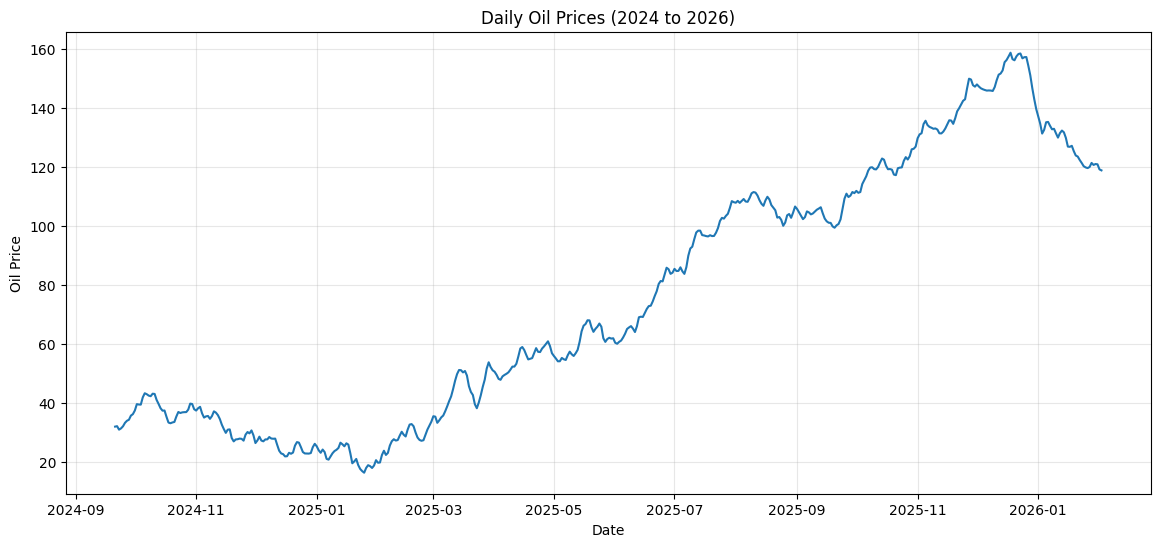

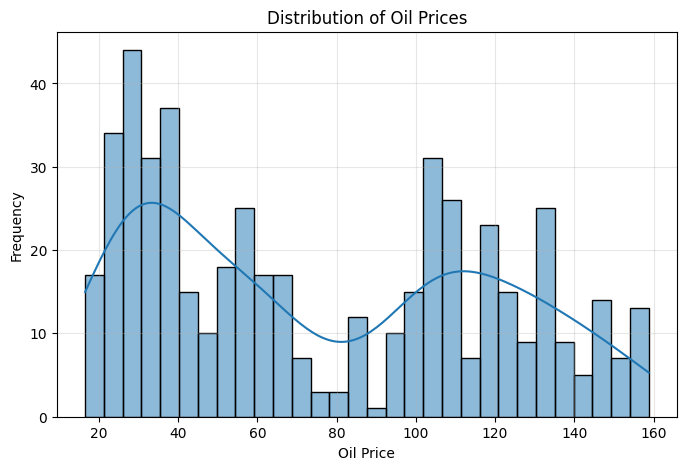

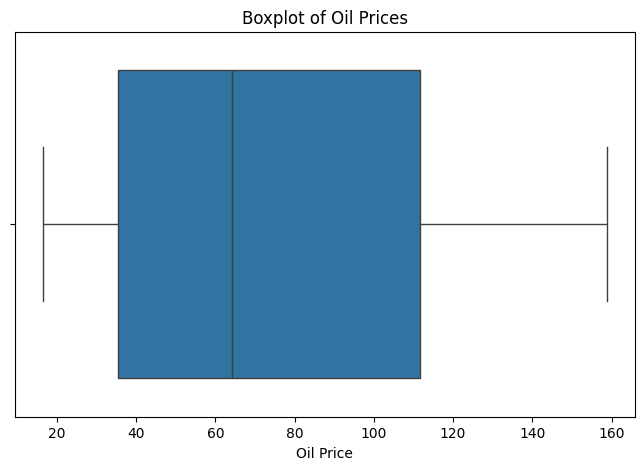

In [7]:
# ============================================================
# INITIAL EDA
# ============================================================

print("Summary statistics:")
print(df["Price"].describe())

plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Price"])
plt.title("Daily Oil Prices (2024 to 2026)")
plt.xlabel("Date")
plt.ylabel("Oil Price")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df["Price"], bins=30, kde=True)
plt.title("Distribution of Oil Prices")
plt.xlabel("Oil Price")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Price"])
plt.title("Boxplot of Oil Prices")
plt.xlabel("Oil Price")
plt.show()

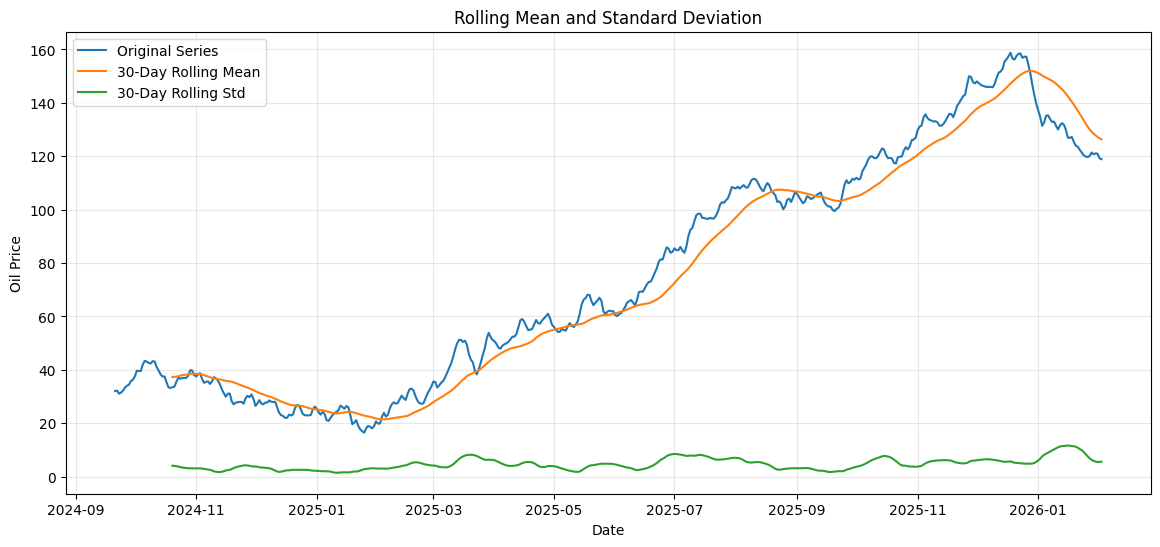

In [8]:
# ============================================================
# ROLLING STATISTICS
# ============================================================

rolling_mean = df["Price"].rolling(window=30).mean()
rolling_std = df["Price"].rolling(window=30).std()

plt.figure(figsize=(14, 6))
plt.plot(df["Price"], label="Original Series")
plt.plot(rolling_mean, label="30-Day Rolling Mean")
plt.plot(rolling_std, label="30-Day Rolling Std")
plt.title("Rolling Mean and Standard Deviation")
plt.xlabel("Date")
plt.ylabel("Oil Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

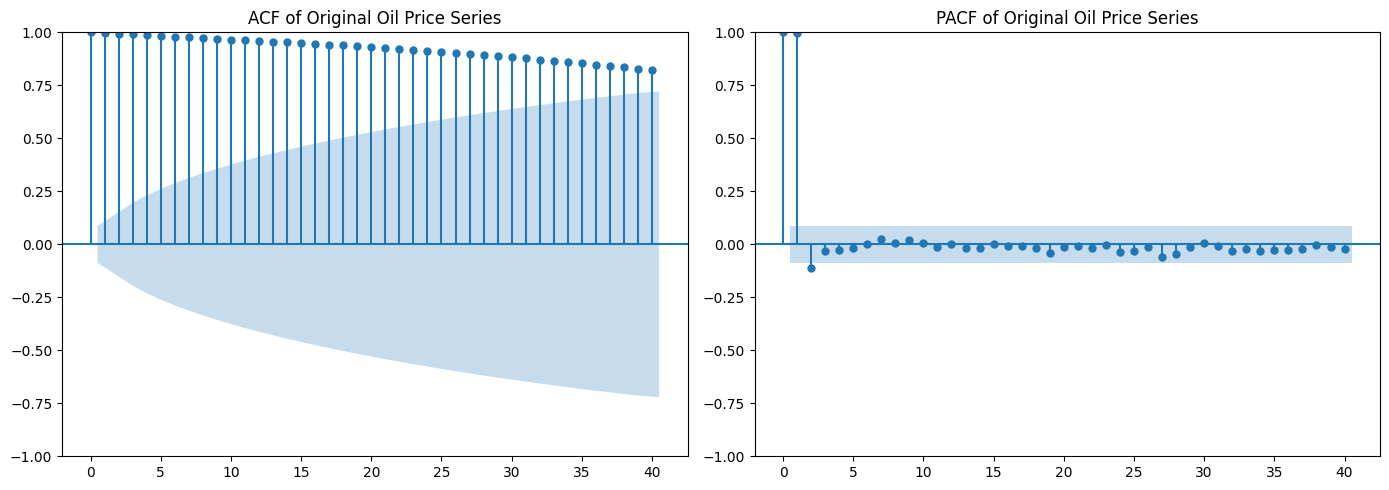

In [9]:
# ============================================================
# ACF AND PACF OF ORIGINAL SERIES
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(df["Price"], ax=ax[0], lags=40)
plot_pacf(df["Price"], ax=ax[1], lags=40, method="ywm")
ax[0].set_title("ACF of Original Oil Price Series")
ax[1].set_title("PACF of Original Oil Price Series")
plt.tight_layout()
plt.show()

## Stationarity Testing

Stationarity is a key requirement in ARIMA modelling. The Augmented Dickey-Fuller (ADF) test and KPSS test are used to assess whether the original oil price series is stationary. If required, differencing is explored to stabilise the mean of the series.

In [10]:
# ============================================================
# STATIONARITY TESTS
# ============================================================

def adf_test(series, title="Series"):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"\nADF Test for {title}")
    print("-" * 50)
    print(f"ADF Statistic : {result[0]:.6f}")
    print(f"p-value       : {result[1]:.6f}")
    print(f"Lags Used     : {result[2]}")
    print(f"N Observations: {result[3]}")
    for key, value in result[4].items():
        print(f"Critical Value ({key}): {value:.6f}")
    if result[1] < 0.05:
        print("Result: Reject H0 -> Series is likely stationary.")
    else:
        print("Result: Fail to reject H0 -> Series is likely non-stationary.")

def kpss_test(series, title="Series"):
    statistic, p_value, n_lags, critical_values = kpss(series.dropna(), regression="c", nlags="auto")
    print(f"\nKPSS Test for {title}")
    print("-" * 50)
    print(f"KPSS Statistic: {statistic:.6f}")
    print(f"p-value       : {p_value:.6f}")
    print(f"Lags Used     : {n_lags}")
    for key, value in critical_values.items():
        print(f"Critical Value ({key}): {value:.6f}")
    if p_value < 0.05:
        print("Result: Reject H0 -> Series is likely non-stationary.")
    else:
        print("Result: Fail to reject H0 -> Series is likely stationary.")

adf_test(df["Price"], title="Original Oil Price")
kpss_test(df["Price"], title="Original Oil Price")


ADF Test for Original Oil Price
--------------------------------------------------
ADF Statistic : -0.546234
p-value       : 0.882674
Lags Used     : 17
N Observations: 482
Critical Value (1%): -3.443990
Critical Value (5%): -2.867555
Critical Value (10%): -2.569974
Result: Fail to reject H0 -> Series is likely non-stationary.

KPSS Test for Original Oil Price
--------------------------------------------------
KPSS Statistic: 3.705619
p-value       : 0.010000
Lags Used     : 12
Critical Value (10%): 0.347000
Critical Value (5%): 0.463000
Critical Value (2.5%): 0.574000
Critical Value (1%): 0.739000
Result: Reject H0 -> Series is likely non-stationary.


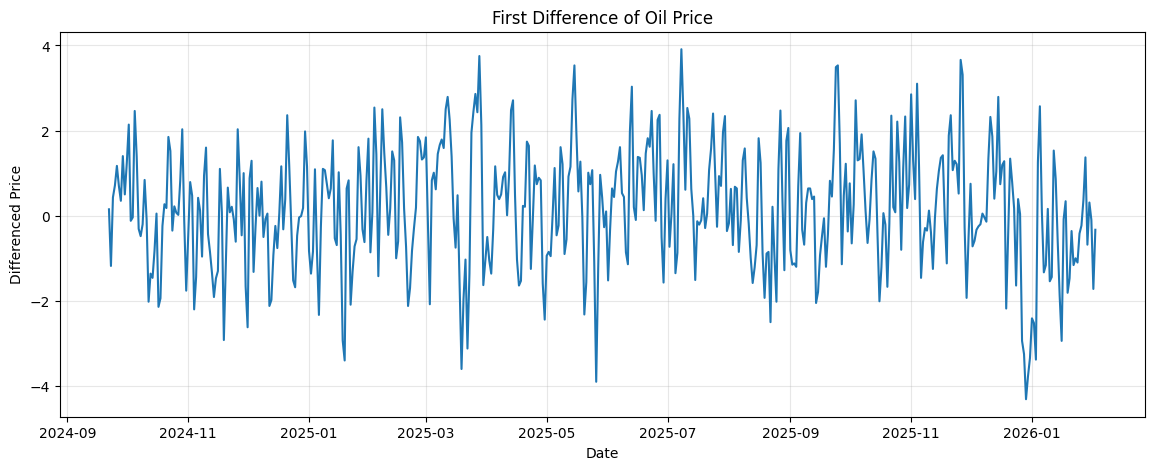

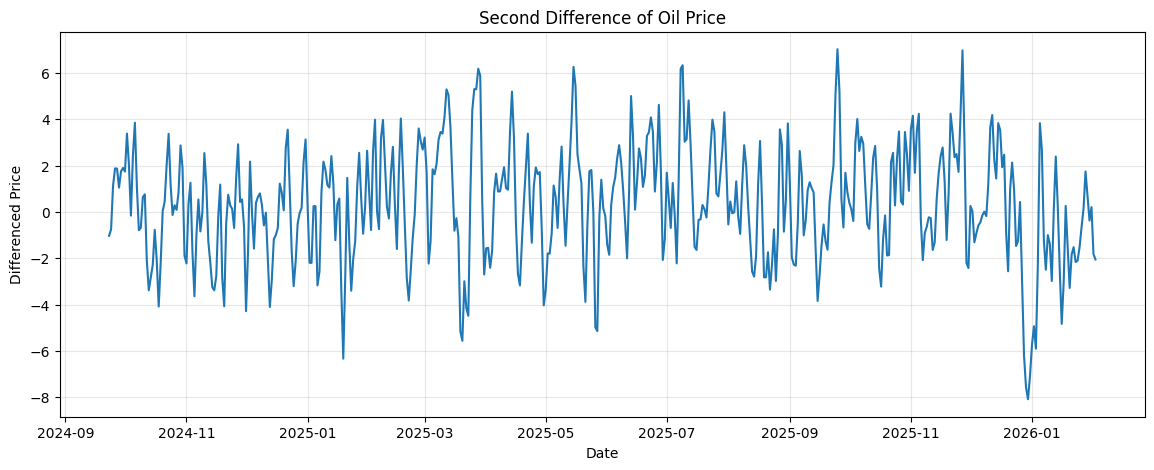


ADF Test for First Differenced Oil Price
--------------------------------------------------
ADF Statistic : -4.541460
p-value       : 0.000165
Lags Used     : 16
N Observations: 482
Critical Value (1%): -3.443990
Critical Value (5%): -2.867555
Critical Value (10%): -2.569974
Result: Reject H0 -> Series is likely stationary.

KPSS Test for First Differenced Oil Price
--------------------------------------------------
KPSS Statistic: 0.190341
p-value       : 0.100000
Lags Used     : 8
Critical Value (10%): 0.347000
Critical Value (5%): 0.463000
Critical Value (2.5%): 0.574000
Critical Value (1%): 0.739000
Result: Fail to reject H0 -> Series is likely stationary.

ADF Test for Second Differenced Oil Price
--------------------------------------------------
ADF Statistic : -3.907620
p-value       : 0.001979
Lags Used     : 18
N Observations: 479
Critical Value (1%): -3.444076
Critical Value (5%): -2.867593
Critical Value (10%): -2.569994
Result: Reject H0 -> Series is likely stationary.

K

In [11]:
# ============================================================
# DIFFERENCING CHECKS
# ============================================================

df["Price_diff1"] = df["Price"].diff(1)
df["Price_diff2"] = df["Price"].diff(2)

plt.figure(figsize=(14, 5))
plt.plot(df["Price_diff1"])
plt.title("First Difference of Oil Price")
plt.xlabel("Date")
plt.ylabel("Differenced Price")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(df["Price_diff2"])
plt.title("Second Difference of Oil Price")
plt.xlabel("Date")
plt.ylabel("Differenced Price")
plt.grid(True, alpha=0.3)
plt.show()

adf_test(df["Price_diff1"], title="First Differenced Oil Price")
kpss_test(df["Price_diff1"], title="First Differenced Oil Price")

adf_test(df["Price_diff2"], title="Second Differenced Oil Price")
kpss_test(df["Price_diff2"], title="Second Differenced Oil Price")

## ACF and PACF Analysis

Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots are examined for the original and differenced series. These plots help to understand the temporal dependence structure and support the ARIMA modelling process.

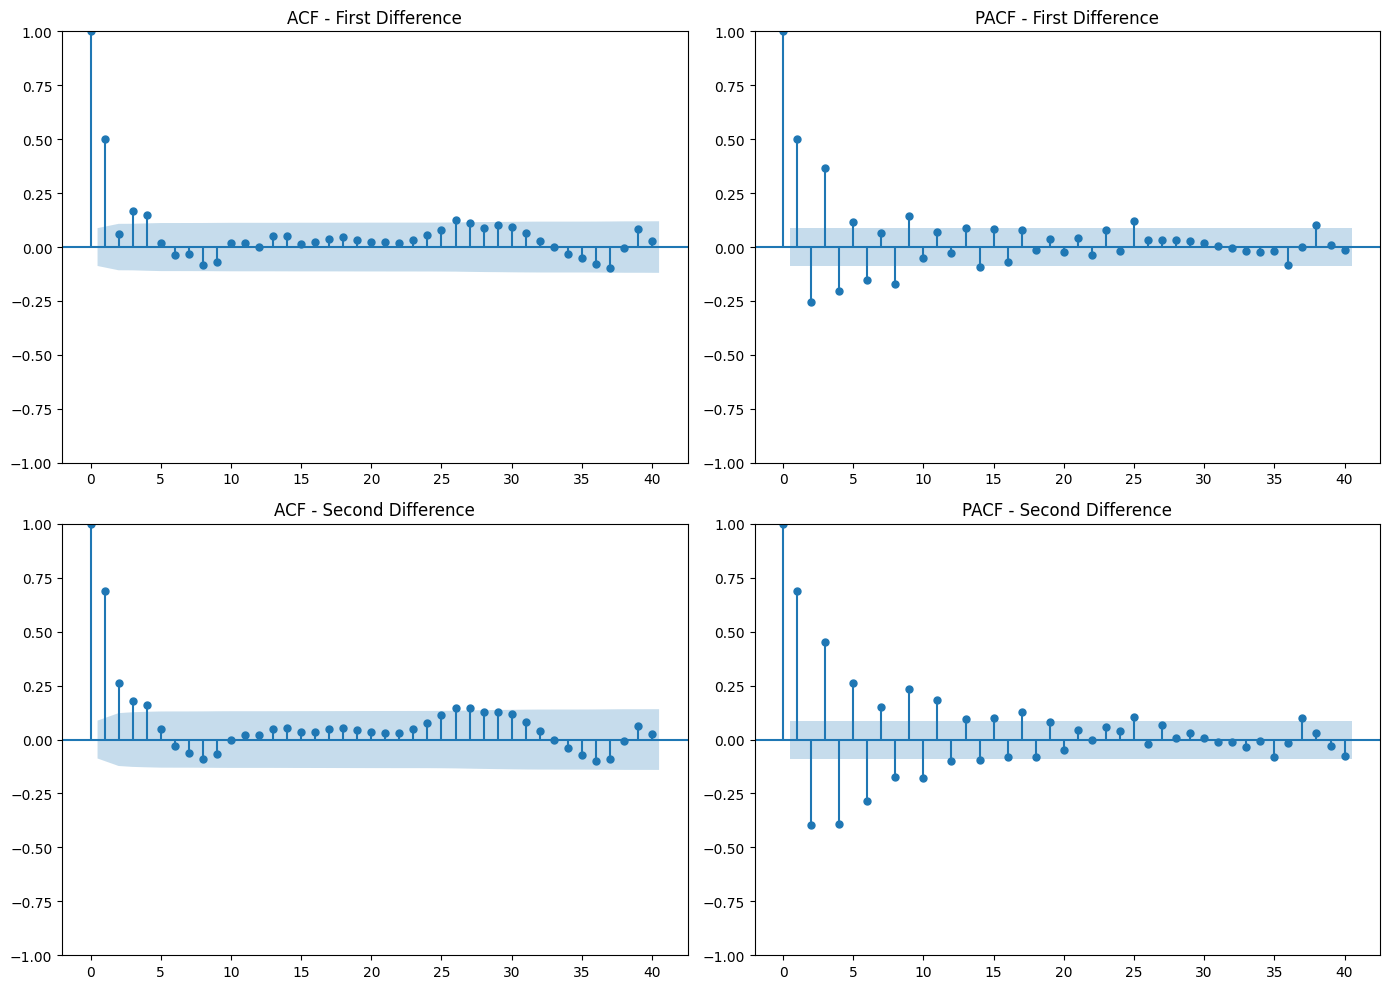

In [12]:
# ============================================================
# ACF AND PACF OF DIFFERENCED SERIES
# ============================================================

fig, ax = plt.subplots(2, 2, figsize=(14, 10))

plot_acf(df["Price_diff1"].dropna(), ax=ax[0, 0], lags=40)
ax[0, 0].set_title("ACF - First Difference")

plot_pacf(df["Price_diff1"].dropna(), ax=ax[0, 1], lags=40, method="ywm")
ax[0, 1].set_title("PACF - First Difference")

plot_acf(df["Price_diff2"].dropna(), ax=ax[1, 0], lags=40)
ax[1, 0].set_title("ACF - Second Difference")

plot_pacf(df["Price_diff2"].dropna(), ax=ax[1, 1], lags=40, method="ywm")
ax[1, 1].set_title("PACF - Second Difference")

plt.tight_layout()
plt.show()

Training observations: 440
Testing observations : 60


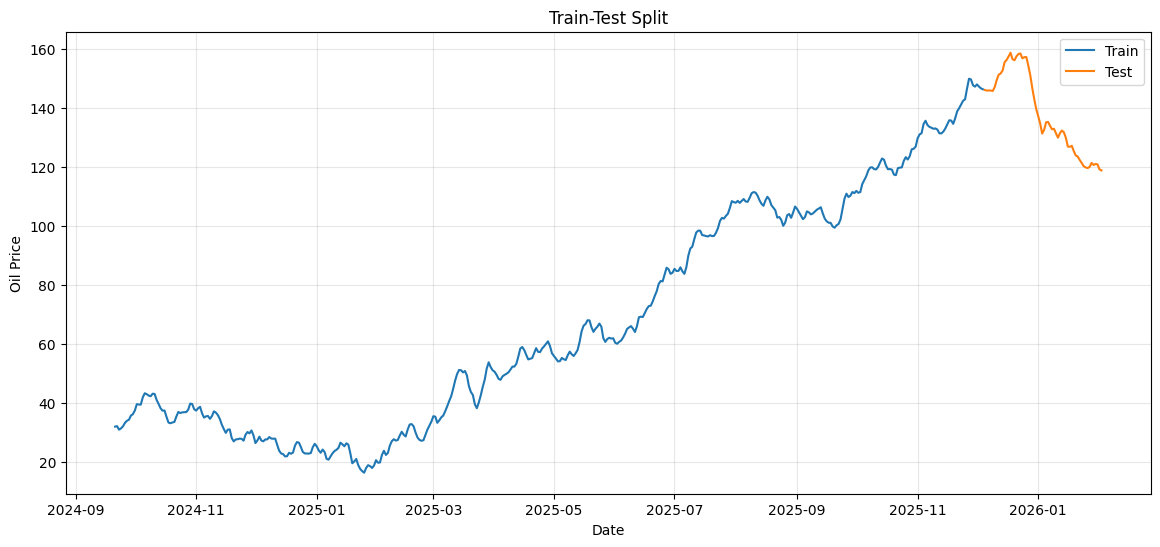

In [13]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

test_size = 60   # last 60 days for test
train = df["Price"][:-test_size]
test = df["Price"][-test_size:]

print("Training observations:", len(train))
print("Testing observations :", len(test))

plt.figure(figsize=(14, 6))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.title("Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Oil Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## ARIMA Model Selection

A full grid search is carried out for all parameter combinations where p ranges from 0 to 8, d ranges from 0 to 2, and q ranges from 0 to 8. Each model is fitted on the training data and evaluated using the Akaike Information Criterion (AIC). The model with the lowest AIC is selected as the best candidate.

In [14]:
# ============================================================
# FULL GRID SEARCH FOR ARIMA(p,d,q)
# p = [0, 8], d = [0, 2], q = [0, 8]
# ============================================================

p_values = range(0, 9)
d_values = range(0, 3)
q_values = range(0, 9)

results = []

print("Starting ARIMA grid search...")

for p, d, q in product(p_values, d_values, q_values):
    order = (p, d, q)
    try:
        model = ARIMA(train, order=order)
        fitted_model = model.fit()

        results.append({
            "order": order,
            "p": p,
            "d": d,
            "q": q,
            "AIC": fitted_model.aic,
            "BIC": fitted_model.bic,
            "LogLik": fitted_model.llf
        })

        print(f"ARIMA{order} -> AIC: {fitted_model.aic:.3f}, BIC: {fitted_model.bic:.3f}")

    except Exception as e:
        print(f"ARIMA{order} failed")
        continue

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="AIC").reset_index(drop=True)

print("\nTop 15 models by AIC:")
print(results_df.head(15))

Starting ARIMA grid search...
ARIMA(0, 0, 0) -> AIC: 4458.302, BIC: 4466.475
ARIMA(0, 0, 1) -> AIC: 3859.371, BIC: 3871.631
ARIMA(0, 0, 2) -> AIC: 3284.983, BIC: 3301.330
ARIMA(0, 0, 3) -> AIC: 2899.421, BIC: 2919.855
ARIMA(0, 0, 4) -> AIC: 2483.959, BIC: 2508.479
ARIMA(0, 0, 5) -> AIC: 2281.998, BIC: 2310.606
ARIMA(0, 0, 6) -> AIC: 2087.712, BIC: 2120.406
ARIMA(0, 0, 7) -> AIC: 2193.230, BIC: 2230.011
ARIMA(0, 0, 8) -> AIC: 2641.067, BIC: 2681.935
ARIMA(0, 1, 0) -> AIC: 1531.798, BIC: 1535.883
ARIMA(0, 1, 1) -> AIC: 1247.819, BIC: 1255.988
ARIMA(0, 1, 2) -> AIC: 1249.783, BIC: 1262.036
ARIMA(0, 1, 3) -> AIC: 1251.343, BIC: 1267.681
ARIMA(0, 1, 4) -> AIC: 1247.397, BIC: 1267.819
ARIMA(0, 1, 5) -> AIC: 1244.277, BIC: 1268.784
ARIMA(0, 1, 6) -> AIC: 1246.120, BIC: 1274.712
ARIMA(0, 1, 7) -> AIC: 1247.922, BIC: 1280.598
ARIMA(0, 1, 8) -> AIC: 1249.864, BIC: 1286.624
ARIMA(0, 2, 0) -> AIC: 1538.196, BIC: 1542.278
ARIMA(0, 2, 1) -> AIC: 1513.997, BIC: 1522.161
ARIMA(0, 2, 2) -> AIC: 1243.77

In [15]:
# ============================================================
# SELECT BEST MODEL BY AIC
# ============================================================

best_model_row = results_df.iloc[0]
best_order = best_model_row["order"]

print("Best ARIMA order based on AIC:", best_order)
print("Best AIC:", best_model_row["AIC"])
print("Best BIC:", best_model_row["BIC"])
print("Best LogLik:", best_model_row["LogLik"])

Best ARIMA order based on AIC: (4, 2, 6)
Best AIC: 1240.0648877475649
Best BIC: 1284.9692957617058
Best LogLik: -609.0324438737824


In [16]:
# ============================================================
# FIT BEST MODEL
# ============================================================

best_model = ARIMA(train, order=best_order)
best_model_fit = best_model.fit()

print(best_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                  440
Model:                 ARIMA(4, 2, 6)   Log Likelihood                -609.032
Date:                Tue, 10 Mar 2026   AIC                           1240.065
Time:                        14:25:49   BIC                           1284.969
Sample:                    09-21-2024   HQIC                          1257.783
                         - 12-04-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6052      0.057     10.653      0.000       0.494       0.716
ar.L2         -1.0284      0.058    -17.696      0.000      -1.142      -0.915
ar.L3          0.6109      0.054     11.225      0.0

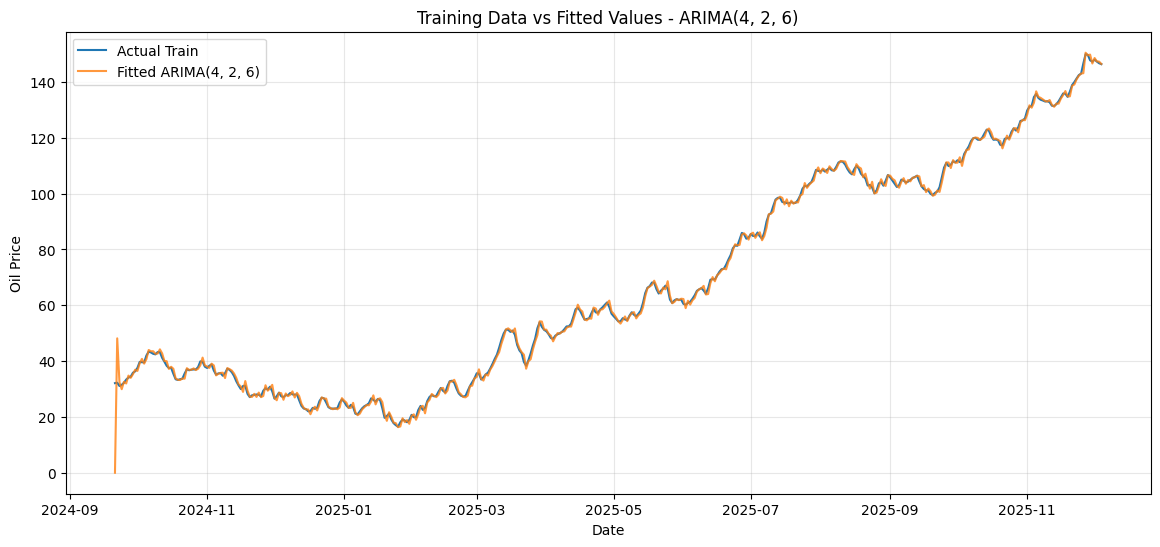

In [17]:
# ============================================================
# FITTED VALUES ON TRAINING SET
# ============================================================

train_fitted = best_model_fit.fittedvalues

plt.figure(figsize=(14, 6))
plt.plot(train, label="Actual Train")
plt.plot(train_fitted, label=f"Fitted ARIMA{best_order}", alpha=0.8)
plt.title(f"Training Data vs Fitted Values - ARIMA{best_order}")
plt.xlabel("Date")
plt.ylabel("Oil Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Residual Diagnostics

After fitting the best ARIMA model, residual diagnostics are performed to evaluate the adequacy of the model. This includes residual plots, histogram, Q-Q plot, residual ACF, and the Ljung-Box test to check whether the residuals behave like white noise.

Residual summary:
count    440.000000
mean       0.098364
std        1.963500
min      -15.900015
25%       -0.568969
50%        0.057887
75%        0.718938
max       32.100000
dtype: float64


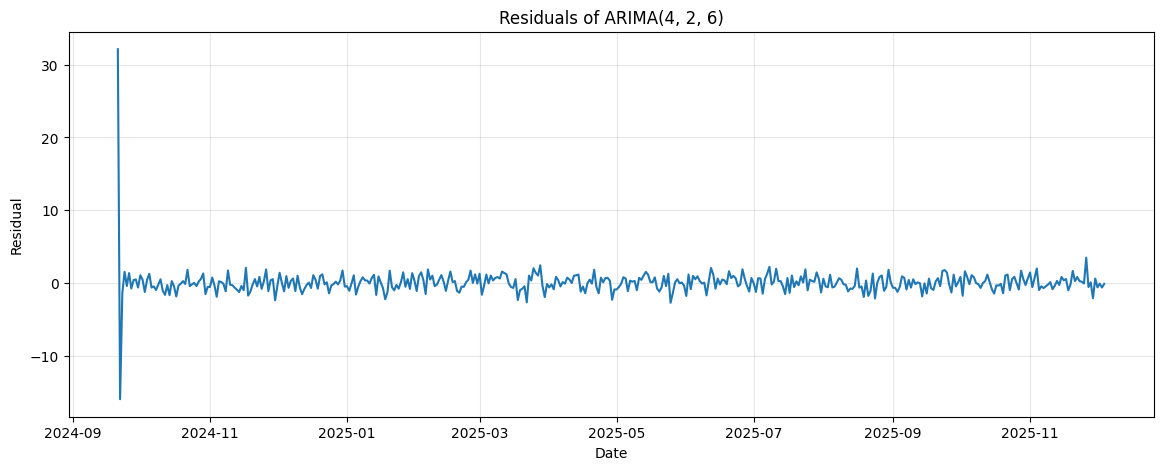

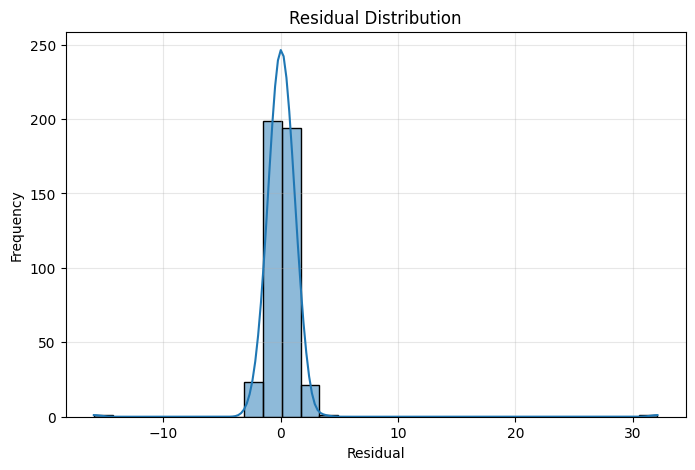

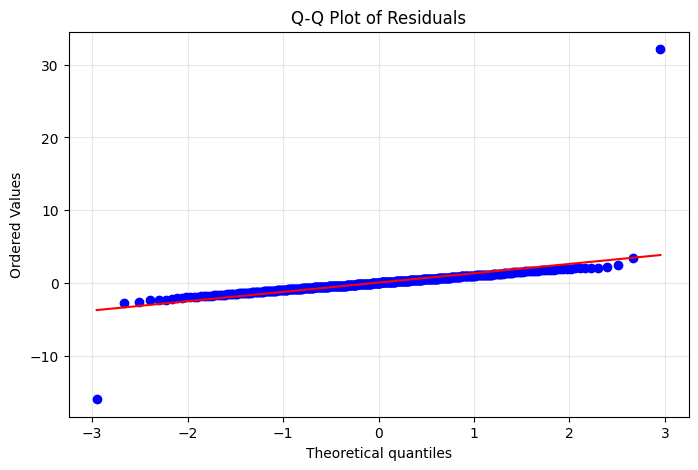

<Figure size 1000x500 with 0 Axes>

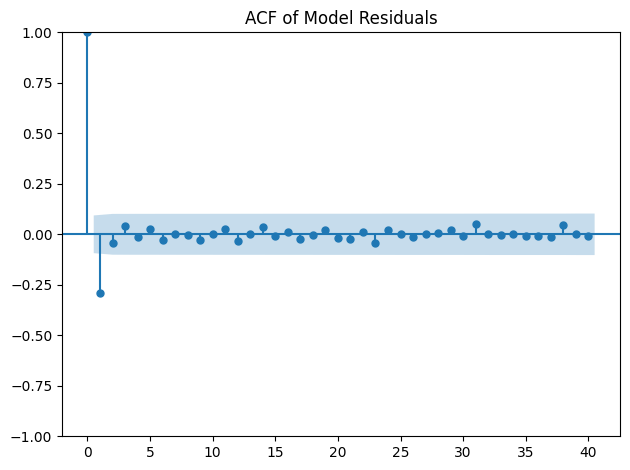


Ljung-Box Test Results:
      lb_stat  lb_pvalue
10  40.272972   0.000015
20  42.309524   0.002520
30  44.058870   0.047110


In [18]:
# ============================================================
# RESIDUAL DIAGNOSTICS
# ============================================================

residuals = best_model_fit.resid

print("Residual summary:")
print(residuals.describe())

# Residual time plot
plt.figure(figsize=(14, 5))
plt.plot(residuals)
plt.title(f"Residuals of ARIMA{best_order}")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True, alpha=0.3)
plt.show()

# Histogram of residuals
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

# Q-Q plot
plt.figure(figsize=(8, 5))
probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.grid(True, alpha=0.3)
plt.show()

# Residual ACF
plt.figure(figsize=(10, 5))
plot_acf(residuals.dropna(), lags=40)
plt.title("ACF of Model Residuals")
plt.tight_layout()
plt.show()

# Ljung-Box test
ljung_box_results = acorr_ljungbox(residuals.dropna(), lags=[10, 20, 30], return_df=True)
print("\nLjung-Box Test Results:")
print(ljung_box_results)

## 7. Model Evaluation

The selected ARIMA model is evaluated on the test set using out-of-sample forecasting. Prediction accuracy is assessed using Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and optionally Mean Absolute Percentage Error (MAPE).

Test RMSE: 23.9591
Test MAE : 19.0998


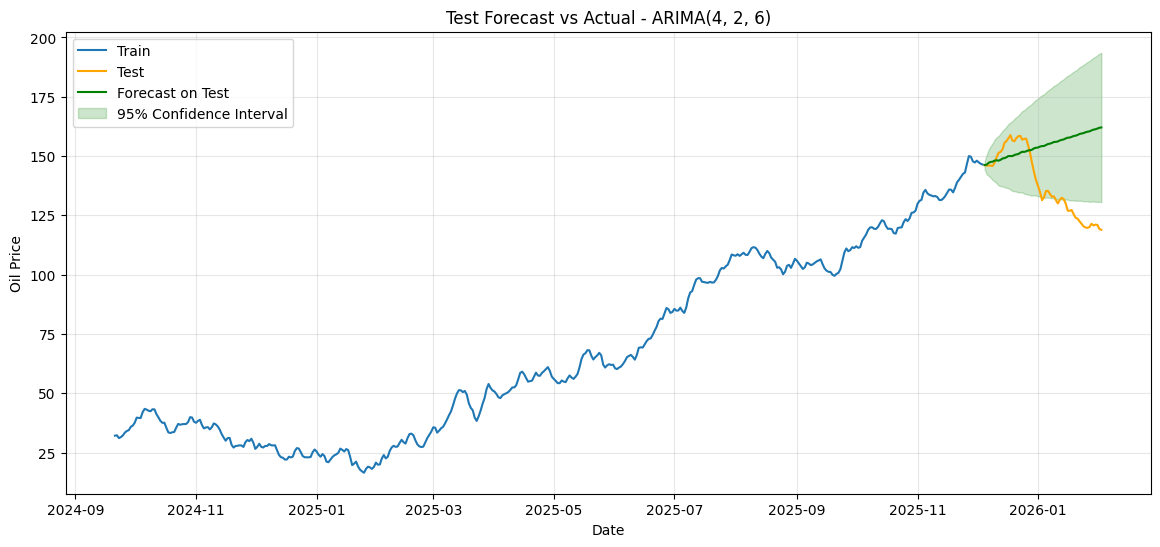

In [19]:
# ============================================================
# TEST SET FORECAST AND PERFORMANCE
# ============================================================

test_forecast_result = best_model_fit.get_forecast(steps=len(test))
test_forecast_mean = test_forecast_result.predicted_mean
test_forecast_ci = test_forecast_result.conf_int()

rmse = np.sqrt(mean_squared_error(test, test_forecast_mean))
mae = mean_absolute_error(test, test_forecast_mean)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE : {mae:.4f}")

plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test", color="orange")
plt.plot(test.index, test_forecast_mean, label="Forecast on Test", color="green")
plt.fill_between(
    test.index,
    test_forecast_ci.iloc[:, 0],
    test_forecast_ci.iloc[:, 1],
    color="green",
    alpha=0.2,
    label="95% Confidence Interval"
)
plt.title(f"Test Forecast vs Actual - ARIMA{best_order}")
plt.xlabel("Date")
plt.ylabel("Oil Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
# ============================================================
# ACTUAL VS PREDICTED TABLE
# ============================================================

comparison_df = pd.DataFrame({
    "Actual": test,
    "Predicted": test_forecast_mean
})

comparison_df["Error"] = comparison_df["Actual"] - comparison_df["Predicted"]
comparison_df["Absolute_Error"] = np.abs(comparison_df["Error"])

print(comparison_df.head(20))

            Actual   Predicted     Error  Absolute_Error
2025-12-05  146.15  146.206412 -0.056412        0.056412
2025-12-06  145.95  146.379395 -0.429395        0.429395
2025-12-07  146.00  147.147035 -1.147035        1.147035
2025-12-08  145.96  147.516287 -1.556287        1.556287
2025-12-09  145.82  147.612057 -1.792057        1.792057
2025-12-10  147.16  148.055733 -0.895733        0.895733
2025-12-11  149.48  148.215267  1.264733        1.264733
2025-12-12  151.34  148.034796  3.305204        3.305204
2025-12-13  151.74  148.398240  3.341760        3.341760
2025-12-14  152.78  148.955352  3.824648        3.824648
2025-12-15  155.57  149.117071  6.452929        6.452929
2025-12-16  156.31  149.477108  6.832892        6.832892
2025-12-17  157.50  149.994959  7.505041        7.505041
2025-12-18  158.78  149.989380  8.790620        8.790620
2025-12-19  156.60  149.980003  6.619997        6.619997
2025-12-20  156.22  150.425423  5.794577        5.794577
2025-12-21  157.56  150.688893 

In [21]:
# ============================================================
# REFIT BEST MODEL ON FULL SERIES
# ============================================================

final_model = ARIMA(df["Price"], order=best_order)
final_model_fit = final_model.fit()

print(final_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                  500
Model:                 ARIMA(4, 2, 6)   Log Likelihood                -706.285
Date:                Tue, 10 Mar 2026   AIC                           1434.569
Time:                        14:25:52   BIC                           1480.886
Sample:                    09-21-2024   HQIC                          1452.747
                         - 02-02-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5310      0.238      2.231      0.026       0.065       0.998
ar.L2         -0.7445      0.154     -4.848      0.000      -1.045      -0.443
ar.L3          0.6529      0.161      4.066      0.0

## Forecasting 24 Months into the Future

The best ARIMA model is refitted on the full dataset and used to forecast approximately 24 months ahead. Forecasts are produced on the original oil price scale, and 95% confidence intervals are added to show the uncertainty around future predictions.

In [22]:
# ============================================================
# FORECAST 24 MONTHS INTO THE FUTURE
# ============================================================

forecast_steps = 730   # approx 24 months for daily data

future_forecast_result = final_model_fit.get_forecast(steps=forecast_steps)
future_forecast_mean = future_forecast_result.predicted_mean
future_forecast_ci = future_forecast_result.conf_int()

# Create future date index
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps, freq="D")

forecast_df = pd.DataFrame({
    "Forecast": future_forecast_mean.values,
    "Lower_CI": future_forecast_ci.iloc[:, 0].values,
    "Upper_CI": future_forecast_ci.iloc[:, 1].values
}, index=future_dates)

print(forecast_df.head())
print(forecast_df.tail())

              Forecast    Lower_CI    Upper_CI
2026-02-03  119.195745  117.247254  121.144236
2026-02-04  118.877728  114.601279  123.154177
2026-02-05  118.368208  112.619994  124.116421
2026-02-06  118.330106  111.261839  125.398373
2026-02-07  118.477679  110.043538  126.911819
             Forecast    Lower_CI    Upper_CI
2028-01-29  73.844165 -623.754714  771.443045
2028-01-30  73.782189 -625.113172  772.677550
2028-01-31  73.720213 -626.472428  773.912854
2028-02-01  73.658237 -627.832482  775.148956
2028-02-02  73.596261 -629.193334  776.385856


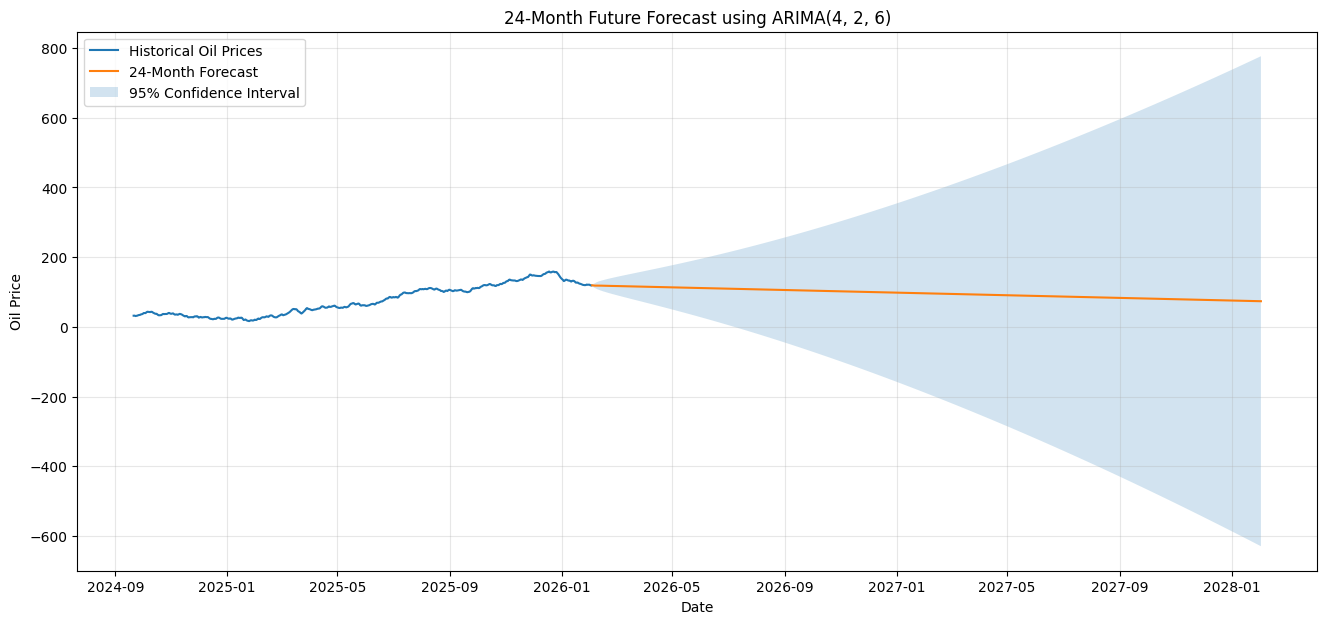

In [23]:
# ============================================================
# PLOT FUTURE FORECAST
# ============================================================

plt.figure(figsize=(16, 7))
plt.plot(df.index, df["Price"], label="Historical Oil Prices")
plt.plot(forecast_df.index, forecast_df["Forecast"], label="24-Month Forecast")
plt.fill_between(
    forecast_df.index,
    forecast_df["Lower_CI"],
    forecast_df["Upper_CI"],
    alpha=0.2,
    label="95% Confidence Interval"
)
plt.title(f"24-Month Future Forecast using ARIMA{best_order}")
plt.xlabel("Date")
plt.ylabel("Oil Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

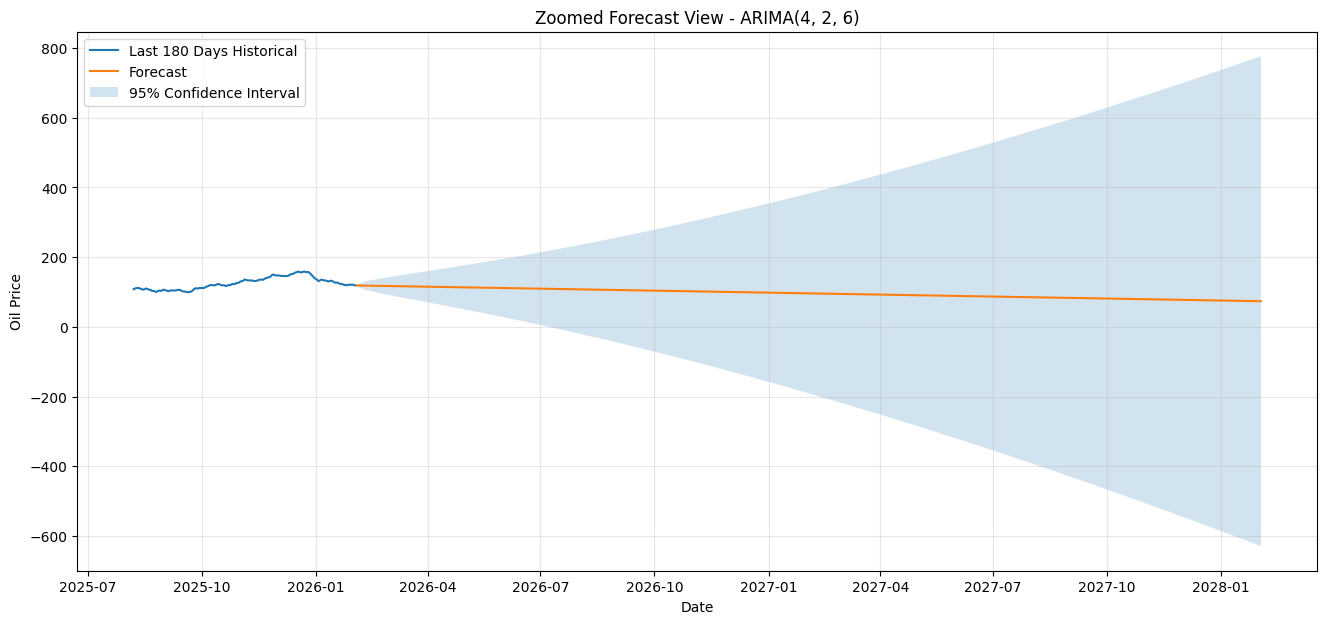

In [24]:
# ============================================================
# ZOOMED FORECAST PLOT
# ============================================================

plt.figure(figsize=(16, 7))
plt.plot(df["Price"].iloc[-180:], label="Last 180 Days Historical")
plt.plot(forecast_df.index, forecast_df["Forecast"], label="Forecast")
plt.fill_between(
    forecast_df.index,
    forecast_df["Lower_CI"],
    forecast_df["Upper_CI"],
    alpha=0.2,
    label="95% Confidence Interval"
)
plt.title(f"Zoomed Forecast View - ARIMA{best_order}")
plt.xlabel("Date")
plt.ylabel("Oil Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [25]:
# ============================================================
# SAVE MODEL SEARCH RESULTS
# ============================================================

results_df.to_csv("arima_grid_search_results.csv", index=False)
forecast_df.to_csv("oil_price_24_month_forecast.csv")

print("Saved:")
print("- arima_grid_search_results.csv")
print("- oil_price_24_month_forecast.csv")

Saved:
- arima_grid_search_results.csv
- oil_price_24_month_forecast.csv


In [26]:
# ============================================================
# TOP 10 BEST MODELS
# ============================================================

top_10_models = results_df.head(10).copy()
print(top_10_models)

       order  p  d  q          AIC          BIC      LogLik
0  (4, 2, 6)  4  2  6  1240.064888  1284.969296 -609.032444
1  (5, 2, 6)  5  2  6  1241.383481  1290.370108 -608.691740
2  (4, 2, 7)  4  2  7  1241.561865  1290.548492 -608.780933
3  (5, 2, 3)  5  2  3  1241.763659  1278.503629 -611.881829
4  (8, 2, 2)  8  2  2  1242.003702  1286.908110 -610.001851
5  (2, 2, 4)  2  2  4  1242.719738  1271.295270 -614.359869
6  (2, 1, 3)  2  1  3  1242.811630  1267.318626 -615.405815
7  (4, 2, 8)  4  2  8  1242.898011  1295.966857 -608.449006
8  (0, 2, 6)  0  2  6  1242.922471  1271.498003 -614.461235
9  (8, 2, 3)  8  2  3  1243.173606  1292.160233 -609.586803


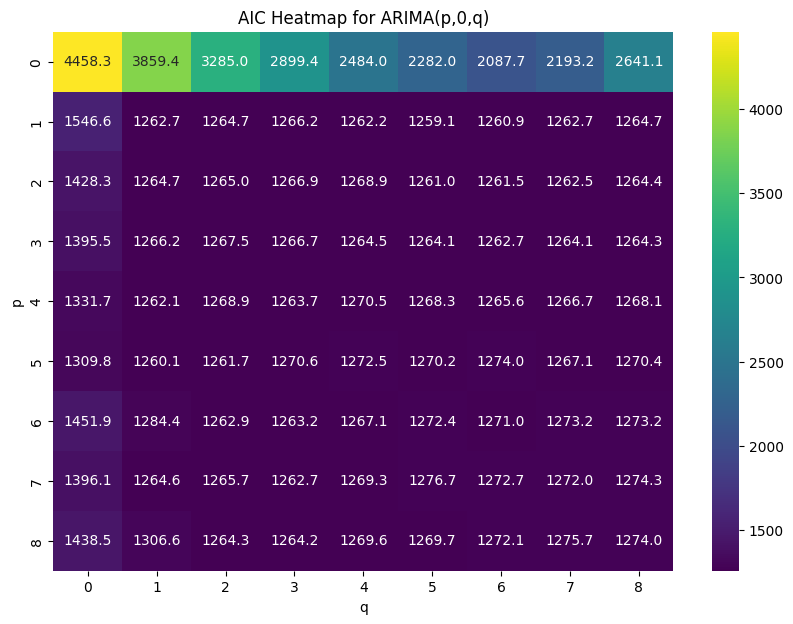

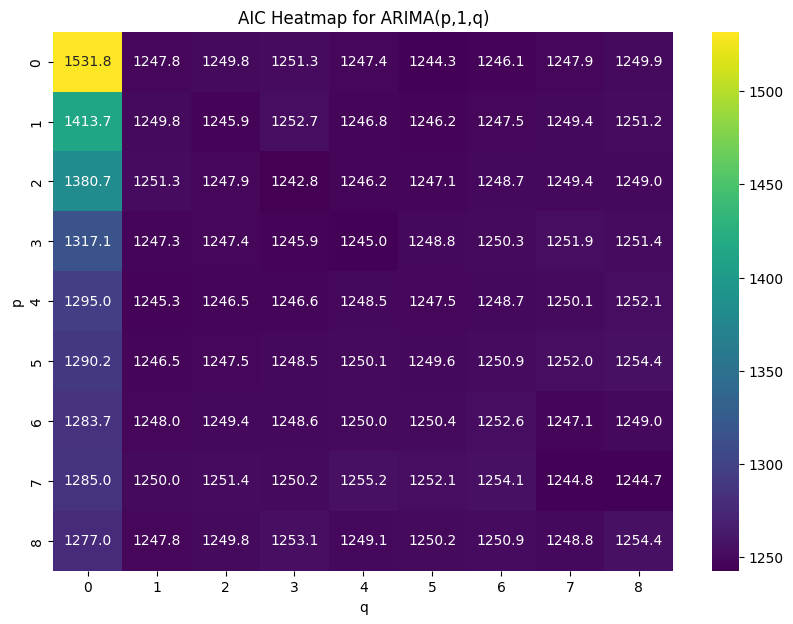

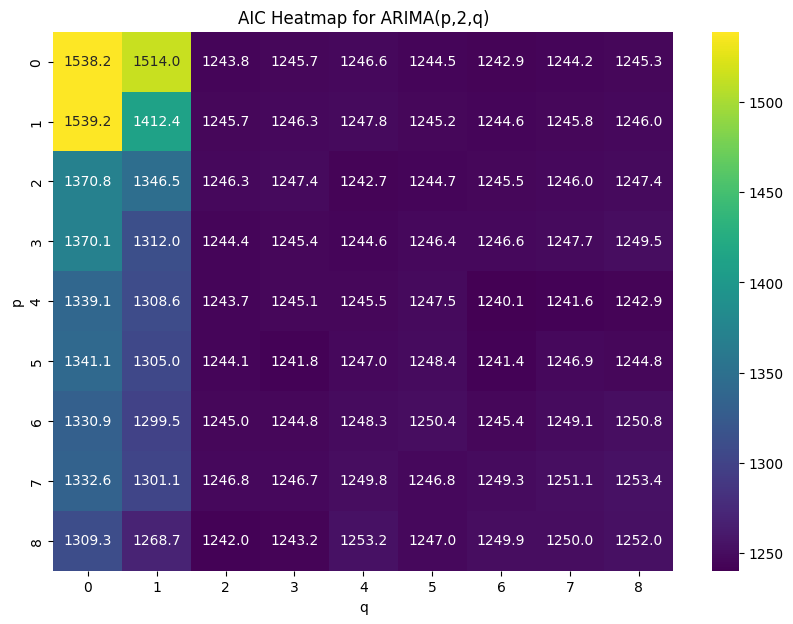

In [27]:
# ============================================================
# AIC HEATMAP FOR EACH d
# ============================================================

for d in d_values:
    subset = results_df[results_df["d"] == d].copy()
    pivot_table = subset.pivot(index="p", columns="q", values="AIC")

    plt.figure(figsize=(10, 7))
    sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap="viridis")
    plt.title(f"AIC Heatmap for ARIMA(p,{d},q)")
    plt.xlabel("q")
    plt.ylabel("p")
    plt.show()

In [28]:
# ============================================================
# FINAL INTERPRETATION SUMMARY
# ============================================================

print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)
print(f"Best ARIMA order selected by AIC: {best_order}")
print(f"Best model AIC: {best_model_row['AIC']:.4f}")
print(f"Best model BIC: {best_model_row['BIC']:.4f}")
print(f"Best model Log-Likelihood: {best_model_row['LogLik']:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE: {mae:.4f}")
print("\nResidual diagnostics were checked using:")
print("- residual time plot")
print("- residual histogram")
print("- Q-Q plot")
print("- residual ACF")
print("- Ljung-Box test")
print("\nFuture forecast horizon: 24 months (~730 daily steps)")
print("Forecasts are shown on the original oil price scale.")
print("=" * 70)

FINAL SUMMARY
Best ARIMA order selected by AIC: (4, 2, 6)
Best model AIC: 1240.0649
Best model BIC: 1284.9693
Best model Log-Likelihood: -609.0324
Test RMSE: 23.9591
Test MAE: 19.0998

Residual diagnostics were checked using:
- residual time plot
- residual histogram
- Q-Q plot
- residual ACF
- Ljung-Box test

Future forecast horizon: 24 months (~730 daily steps)
Forecasts are shown on the original oil price scale.


In [29]:
# ============================================================
# EXTRA EVALUATION METRICS
# ============================================================

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

test_mape = mape(test, test_forecast_mean)

print(f"Test RMSE : {rmse:.4f}")
print(f"Test MAE  : {mae:.4f}")
print(f"Test MAPE : {test_mape:.4f}%")

Test RMSE : 23.9591
Test MAE  : 19.0998
Test MAPE : 14.9358%


Rolling Forecast RMSE: 1.2002
Rolling Forecast MAE : 0.9836


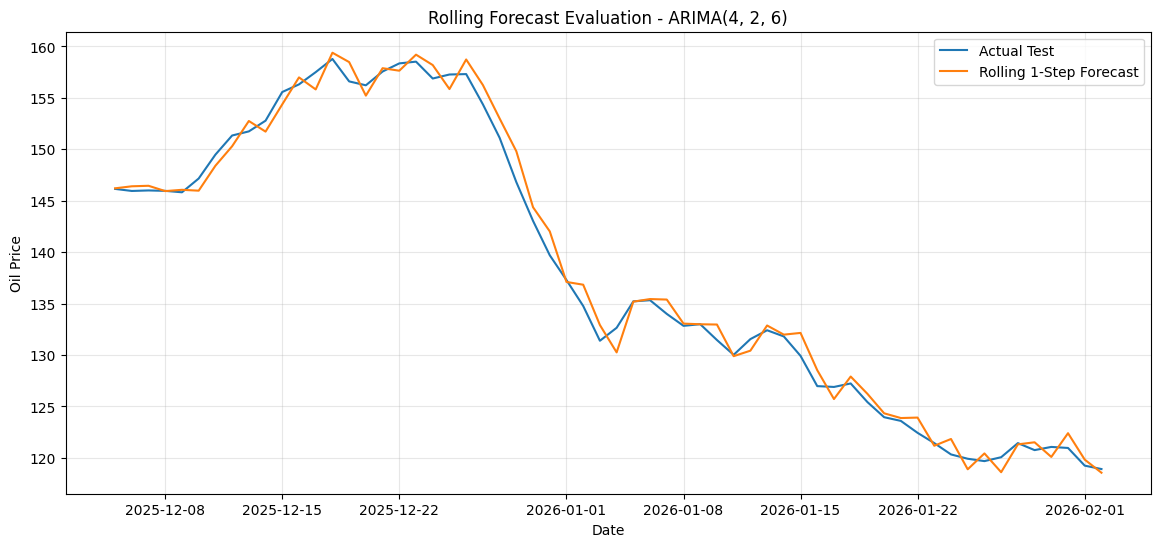

In [30]:
# ============================================================
# ROLLING FORECAST EVALUATION
# ============================================================

history = list(train)
rolling_predictions = []

for t in range(len(test)):
    try:
        model = ARIMA(history, order=best_order)
        model_fit = model.fit()
        yhat = model_fit.forecast(steps=1)[0]
        rolling_predictions.append(yhat)
        history.append(test.iloc[t])
    except Exception as e:
        rolling_predictions.append(np.nan)
        history.append(test.iloc[t])

rolling_pred_series = pd.Series(rolling_predictions, index=test.index)

rolling_rmse = np.sqrt(mean_squared_error(test.dropna(), rolling_pred_series.dropna()))
rolling_mae = mean_absolute_error(test.dropna(), rolling_pred_series.dropna())

print(f"Rolling Forecast RMSE: {rolling_rmse:.4f}")
print(f"Rolling Forecast MAE : {rolling_mae:.4f}")

plt.figure(figsize=(14, 6))
plt.plot(test.index, test, label="Actual Test")
plt.plot(rolling_pred_series.index, rolling_pred_series, label="Rolling 1-Step Forecast")
plt.title(f"Rolling Forecast Evaluation - ARIMA{best_order}")
plt.xlabel("Date")
plt.ylabel("Oil Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Prophet Model

In addition to ARIMA, Prophet was used as an alternative forecasting model. Prophet is designed for time series with trend and seasonal patterns and was tuned using multiple values of changepoint prior scale, seasonality prior scale, and seasonality mode. The best Prophet configuration was selected based on forecasting accuracy on the test set.

In [31]:
from prophet import Prophet

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, root_mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [32]:
# ============================================================
# COMMON EVALUATION FUNCTION
# ============================================================

def evaluate_forecast(y_true, y_pred, model_name="Model"):
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name} Performance")
    print("-" * 50)
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MAPE : {mape:.4f}%")
    print(f"R²   : {r2:.4f}")

    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2": r2
    }

Train length: 440
Test length : 60


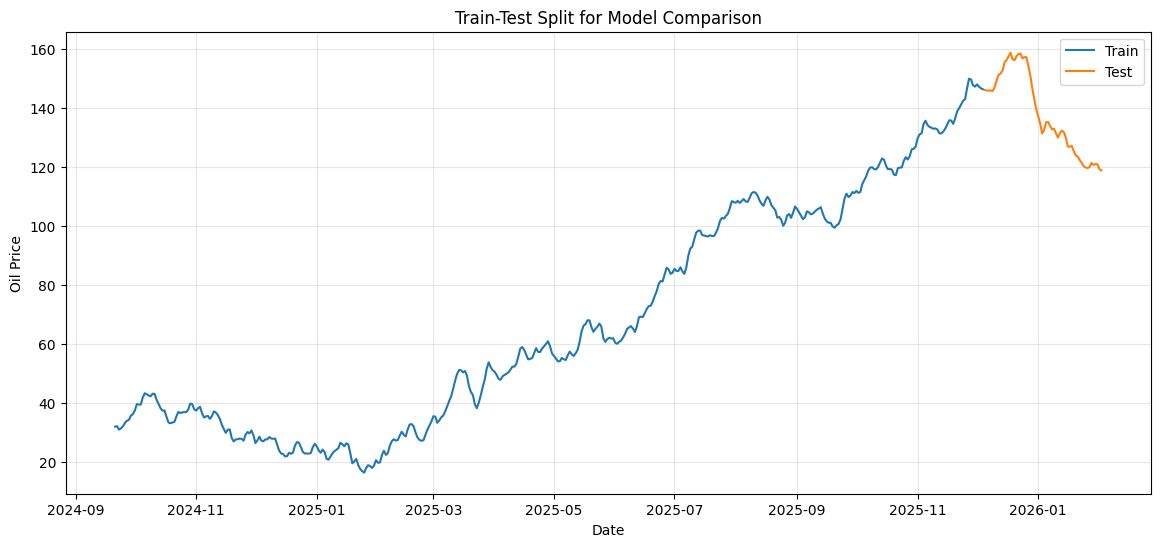

In [33]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

test_size = 60

series = df["Price"].copy()

train = series.iloc[:-test_size]
test = series.iloc[-test_size:]

print("Train length:", len(train))
print("Test length :", len(test))

plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.title("Train-Test Split for Model Comparison")
plt.xlabel("Date")
plt.ylabel("Oil Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [34]:
# ============================================================
# PREPARE DATA FOR PROPHET
# ============================================================

prophet_train = train.reset_index()
prophet_train.columns = ["ds", "y"]

prophet_test = test.reset_index()
prophet_test.columns = ["ds", "y"]

print(prophet_train.head())
print(prophet_test.head())

          ds      y
0 2024-09-21  32.10
1 2024-09-22  32.25
2 2024-09-23  31.07
3 2024-09-24  31.50
4 2024-09-25  32.21
          ds       y
0 2025-12-05  146.15
1 2025-12-06  145.95
2 2025-12-07  146.00
3 2025-12-08  145.96
4 2025-12-09  145.82


In [35]:
# ============================================================
# PROPHET PARAMETER SEARCH
# ============================================================

prophet_results = []

changepoint_prior_scale_values = [0.001, 0.01, 0.05, 0.1, 0.5]
seasonality_prior_scale_values = [0.01, 0.1, 1.0, 5.0, 10.0]
seasonality_modes = ["additive", "multiplicative"]

for cps in changepoint_prior_scale_values:
    for sps in seasonality_prior_scale_values:
        for smode in seasonality_modes:
            try:
                model = Prophet(
                    daily_seasonality=False,
                    weekly_seasonality=True,
                    yearly_seasonality=True,
                    changepoint_prior_scale=cps,
                    seasonality_prior_scale=sps,
                    seasonality_mode=smode,
                    interval_width=0.95
                )

                model.fit(prophet_train)

                future_test = model.make_future_dataframe(periods=len(test), freq="D")
                forecast_test = model.predict(future_test)

                y_pred_test = forecast_test.iloc[-len(test):]["yhat"].values
                y_true_test = prophet_test["y"].values

                rmse = root_mean_squared_error(y_true_test, y_pred_test)
                mae = mean_absolute_error(y_true_test, y_pred_test)
                mape = mean_absolute_percentage_error(y_true_test, y_pred_test) * 100
                r2 = r2_score(y_true_test, y_pred_test)

                prophet_results.append({
                    "changepoint_prior_scale": cps,
                    "seasonality_prior_scale": sps,
                    "seasonality_mode": smode,
                    "RMSE": rmse,
                    "MAE": mae,
                    "MAPE": mape,
                    "R2": r2
                })

                print(f"Prophet(cps={cps}, sps={sps}, mode={smode}) -> RMSE: {rmse:.4f}")

            except Exception as e:
                print(f"Failed Prophet(cps={cps}, sps={sps}, mode={smode})")
                continue

prophet_results_df = pd.DataFrame(prophet_results).sort_values("RMSE").reset_index(drop=True)

print("\nTop 10 Prophet models:")
print(prophet_results_df.head(10))

ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted
ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted


Prophet(cps=0.001, sps=0.01, mode=additive) -> RMSE: 24.0042


ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted


Prophet(cps=0.001, sps=0.01, mode=multiplicative) -> RMSE: 23.0657


ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted


...

Prophet(cps=0.001, sps=5.0, mode=additive) -> RMSE: 25.3855


ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted


Prophet(cps=0.001, sps=5.0, mode=multiplicative) -> RMSE: 67.9452


ERROR:cmdstanpy:Chain [1] error: code '1' Operation not permitted


Prophet(cps=0.001, sps=10.0, mode=additive) -> RMSE: 25.3848
Prophet(cps=0.001, sps=10.0, mode=multiplicative) -> RMSE: 67.7923
Prophet(cps=0.01, sps=0.01, mode=additive) -> RMSE: 22.0284
Prophet(cps=0.01, sps=0.01, mode=multiplicative) -> RMSE: 16.7924
Prophet(cps=0.01, sps=0.1, mode=additive) -> RMSE: 24.2003
Prophet(cps=0.01, sps=0.1, mode=multiplicative) -> RMSE: 23.8167
Prophet(cps=0.01, sps=1.0, mode=additive) -> RMSE: 24.4093
Prophet(cps=0.01, sps=1.0, mode=multiplicative) -> RMSE: 26.4128
Prophet(cps=0.01, sps=5.0, mode=additive) -> RMSE: 23.1314
Prophet(cps=0.01, sps=5.0, mode=multiplicative) -> RMSE: 27.7319
Prophet(cps=0.01, sps=10.0, mode=additive) -> RMSE: 23.2048
Prophet(cps=0.01, sps=10.0, mode=multiplicative) -> RMSE: 24.8292
Prophet(cps=0.05, sps=0.01, mode=additive) -> RMSE: 25.1219
Prophet(cps=0.05, sps=0.01, mode=multiplicative) -> RMSE: 25.0639
Prophet(cps=0.05, sps=0.1, mode=additive) -> RMSE: 31.4614
Prophet(cps=0.05, sps=0.1, mode=multiplicative) -> RMSE: 5.8943

In [36]:
# ============================================================
# FIT BEST PROPHET MODEL
# ============================================================

best_prophet = prophet_results_df.iloc[0]

best_cps = best_prophet["changepoint_prior_scale"]
best_sps = best_prophet["seasonality_prior_scale"]
best_smode = best_prophet["seasonality_mode"]

print("Best Prophet parameters:")
print(best_prophet)

prophet_model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=best_cps,
    seasonality_prior_scale=best_sps,
    seasonality_mode=best_smode,
    interval_width=0.95
)

prophet_model.fit(prophet_train)

Best Prophet parameters:
changepoint_prior_scale              0.05
seasonality_prior_scale               0.1
seasonality_mode           multiplicative
RMSE                             5.894305
MAE                               5.09921
MAPE                             3.873471
R2                               0.813193
Name: 0, dtype: object



Prophet Performance
--------------------------------------------------
RMSE : 5.8943
MAE  : 5.0992
MAPE : 3.8735%
R²   : 0.8132


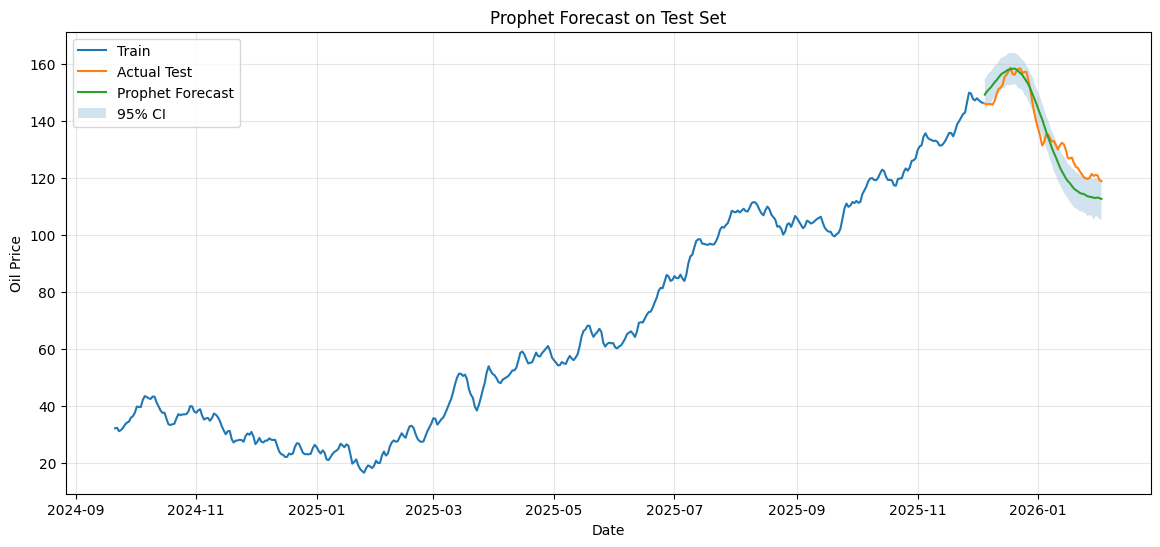

In [37]:
# ============================================================
# PROPHET TEST FORECAST
# ============================================================

future_test = prophet_model.make_future_dataframe(periods=len(test), freq="D")
prophet_forecast_test = prophet_model.predict(future_test)

prophet_test_pred = prophet_forecast_test.iloc[-len(test):]["yhat"].values
prophet_test_lower = prophet_forecast_test.iloc[-len(test):]["yhat_lower"].values
prophet_test_upper = prophet_forecast_test.iloc[-len(test):]["yhat_upper"].values

prophet_metrics = evaluate_forecast(test.values, prophet_test_pred, model_name="Prophet")

plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual Test")
plt.plot(test.index, prophet_test_pred, label="Prophet Forecast")
plt.fill_between(test.index, prophet_test_lower, prophet_test_upper, alpha=0.2, label="95% CI")
plt.title("Prophet Forecast on Test Set")
plt.xlabel("Date")
plt.ylabel("Oil Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

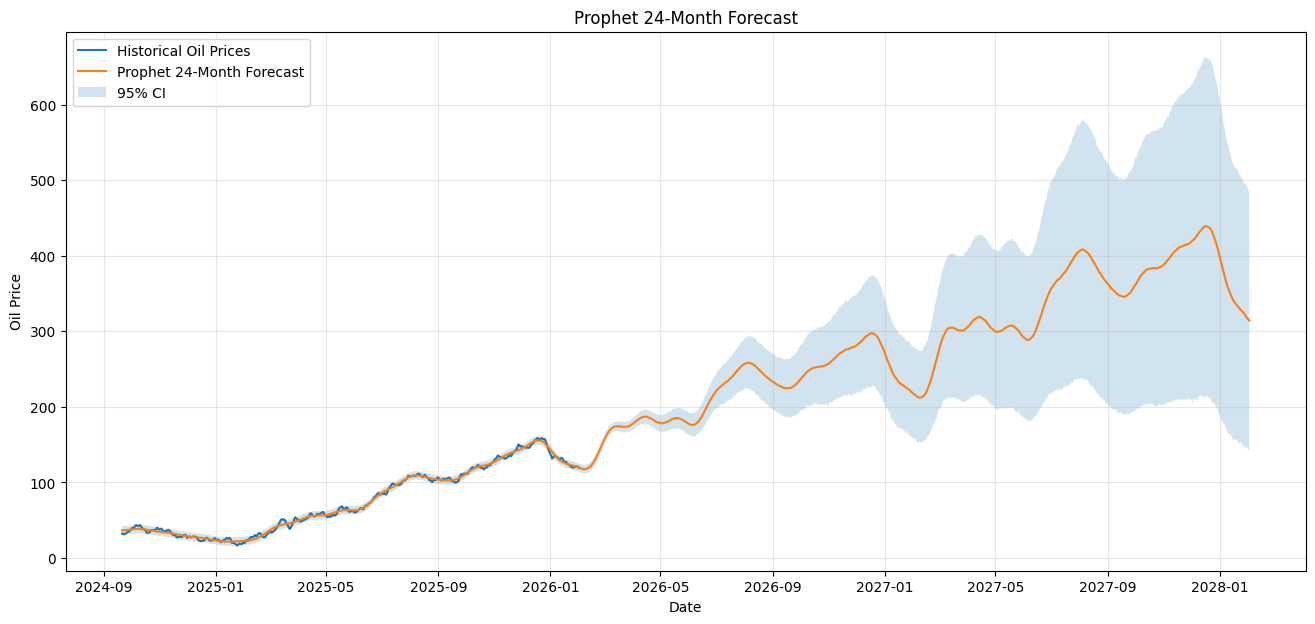

In [38]:
# ============================================================
# PROPHET 24-MONTH FUTURE FORECAST
# ============================================================

prophet_full = df["Price"].reset_index()
prophet_full.columns = ["ds", "y"]

final_prophet_model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=best_cps,
    seasonality_prior_scale=best_sps,
    seasonality_mode=best_smode,
    interval_width=0.95
)

final_prophet_model.fit(prophet_full)

future_24m = final_prophet_model.make_future_dataframe(periods=730, freq="D")
prophet_forecast_24m = final_prophet_model.predict(future_24m)

plt.figure(figsize=(16, 7))
plt.plot(df.index, df["Price"], label="Historical Oil Prices")
plt.plot(prophet_forecast_24m["ds"], prophet_forecast_24m["yhat"], label="Prophet 24-Month Forecast")
plt.fill_between(
    prophet_forecast_24m["ds"],
    prophet_forecast_24m["yhat_lower"],
    prophet_forecast_24m["yhat_upper"],
    alpha=0.2,
    label="95% CI"
)
plt.title("Prophet 24-Month Forecast")
plt.xlabel("Date")
plt.ylabel("Oil Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## LSTM Model

A Long Short-Term Memory (LSTM) neural network was also implemented as a deep learning approach for forecasting oil prices. The series was scaled using MinMaxScaler and converted into supervised learning sequences using sliding windows. Different sequence lengths, numbers of hidden units, dropout values, and batch sizes were tested. The best LSTM model was selected using test-set forecast performance.

In [39]:
# ============================================================
# PREPARE DATA FOR LSTM
# ============================================================

lstm_train = train.values.reshape(-1, 1)
lstm_test = test.values.reshape(-1, 1)

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(lstm_train)
test_scaled = scaler.transform(lstm_test)

print("Train scaled shape:", train_scaled.shape)
print("Test scaled shape :", test_scaled.shape)

Train scaled shape: (440, 1)
Test scaled shape : (60, 1)


In [40]:
# ============================================================
# CREATE LSTM SEQUENCES
# ============================================================

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

sequence_lengths = [7, 14, 30]

In [41]:
# ============================================================
# LSTM HYPERPARAMETER SEARCH
# ============================================================

tf.random.set_seed(42)
np.random.seed(42)

lstm_results = []

units_list = [32, 64]
dropout_list = [0.0, 0.2]
batch_sizes = [16, 32]
epochs_list = [30]
sequence_lengths = [7, 14, 30]

for seq_len in sequence_lengths:
    # Create train sequences
    X_train, y_train = create_sequences(train_scaled, seq_len)

    # Build test sequences using tail of train + full test
    combined = np.concatenate([train_scaled[-seq_len:], test_scaled], axis=0)
    X_test, y_test = create_sequences(combined, seq_len)

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    for units in units_list:
        for dropout in dropout_list:
            for batch_size in batch_sizes:
                for epochs in epochs_list:
                    try:
                        model = keras.Sequential([
                            layers.Input(shape=(seq_len, 1)),
                            layers.LSTM(units, return_sequences=False),
                            layers.Dropout(dropout),
                            layers.Dense(1)
                        ])

                        model.compile(optimizer="adam", loss="mse")

                        early_stop = keras.callbacks.EarlyStopping(
                            monitor="val_loss",
                            patience=8,
                            restore_best_weights=True
                        )

                        history = model.fit(
                            X_train, y_train,
                            validation_split=0.1,
                            epochs=epochs,
                            batch_size=batch_size,
                            verbose=0,
                            callbacks=[early_stop]
                        )

                        pred_scaled = model.predict(X_test, verbose=0)
                        pred = scaler.inverse_transform(pred_scaled).flatten()
                        y_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

                        rmse = root_mean_squared_error(y_true, pred)
                        mae = mean_absolute_error(y_true, pred)
                        mape = mean_absolute_percentage_error(y_true, pred) * 100
                        r2 = r2_score(y_true, pred)

                        lstm_results.append({
                            "sequence_length": seq_len,
                            "units": units,
                            "dropout": dropout,
                            "batch_size": batch_size,
                            "epochs": epochs,
                            "RMSE": rmse,
                            "MAE": mae,
                            "MAPE": mape,
                            "R2": r2
                        })

                        print(
                            f"LSTM(seq={seq_len}, units={units}, dropout={dropout}, "
                            f"batch={batch_size}) -> RMSE: {rmse:.4f}"
                        )

                    except Exception as e:
                        print(
                            f"Failed LSTM(seq={seq_len}, units={units}, dropout={dropout}, "
                            f"batch={batch_size})"
                        )
                        continue

lstm_results_df = pd.DataFrame(lstm_results).sort_values("RMSE").reset_index(drop=True)

print("\nTop 10 LSTM models:")
print(lstm_results_df.head(10))

LSTM(seq=7, units=32, dropout=0.0, batch=16) -> RMSE: 7.2317
LSTM(seq=7, units=32, dropout=0.0, batch=32) -> RMSE: 5.9091


LSTM(seq=7, units=32, dropout=0.2, batch=16) -> RMSE: 6.5122
LSTM(seq=7, units=32, dropout=0.2, batch=32) -> RMSE: 6.6775
LSTM(seq=7, units=64, dropout=0.0, batch=16) -> RMSE: 6.4491
LSTM(seq=7, units=64, dropout=0.0, batch=32) -> RMSE: 6.7897
LSTM(seq=7, units=64, dropout=0.2, batch=16) -> RMSE: 6.5575
LSTM(seq=7, units=64, dropout=0.2, batch=32) -> RMSE: 6.0205
LSTM(seq=14, units=32, dropout=0.0, batch=16) -> RMSE: 11.4244
LSTM(seq=14, units=32, dropout=0.0, batch=32) -> RMSE: 9.4308
LSTM(seq=14, units=32, dropout=0.2, batch=16) -> RMSE: 9.3998
LSTM(seq=14, units=32, dropout=0.2, batch=32) -> RMSE: 8.3443
LSTM(seq=14, units=64, dropout=0.0, batch=16) -> RMSE: 9.7510
LSTM(seq=14, units=64, dropout=0.0, batch=32) -> RMSE: 8.8152
LSTM(seq=14, units=64, dropout=0.2, batch=16) -> RMSE: 10.0298
LSTM(seq=14, units=64, dropout=0.2, batch=32) -> RMSE: 7.4646
LSTM(seq=30, units=32, dropout=0.0, batch=16) -> RMSE: 12.3524
LSTM(seq=30, units=32, dropout=0.0, batch=32) -> RMSE: 9.1280
LSTM(seq=30

In [42]:
# ============================================================
# FIT BEST LSTM MODEL
# ============================================================

best_lstm = lstm_results_df.iloc[0]
print("Best LSTM parameters:")
print(best_lstm)

best_seq = int(best_lstm["sequence_length"])
best_units = int(best_lstm["units"])
best_dropout = float(best_lstm["dropout"])
best_batch = int(best_lstm["batch_size"])
best_epochs = int(best_lstm["epochs"])

X_train, y_train = create_sequences(train_scaled, best_seq)
combined = np.concatenate([train_scaled[-best_seq:], test_scaled], axis=0)
X_test, y_test = create_sequences(combined, best_seq)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

best_lstm_model = keras.Sequential([
    layers.Input(shape=(best_seq, 1)),
    layers.LSTM(best_units, return_sequences=False),
    layers.Dropout(best_dropout),
    layers.Dense(1)
])

best_lstm_model.compile(optimizer="adam", loss="mse")

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history = best_lstm_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=best_epochs,
    batch_size=best_batch,
    verbose=1,
    callbacks=[early_stop]
)

Best LSTM parameters:
sequence_length     7.000000
units              32.000000
dropout             0.000000
batch_size         32.000000
epochs             30.000000
RMSE                5.909091
MAE                 4.687656
MAPE                3.479792
R2                  0.812254
Name: 0, dtype: float64
Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.1640 - val_loss: 0.4506
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0578 - val_loss: 0.1212
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0155 - val_loss: 0.0109
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0131 - val_loss: 0.0164
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0071 - val_loss: 0.0151
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0041 - val_loss: 0.0020
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0023 - val_loss: 5.4712e-04
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0013 - val_loss: 6.4568e-04
Epoch 9/


LSTM Performance
--------------------------------------------------
RMSE : 6.1480
MAE  : 4.6246
MAPE : 3.3778%
R²   : 0.7968


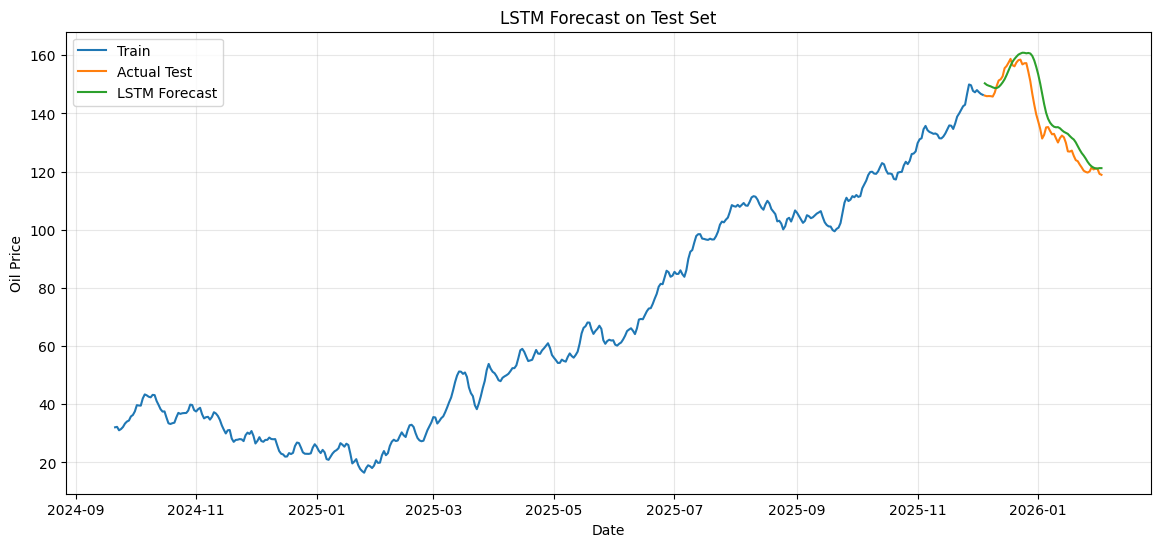

In [43]:
# ============================================================
# LSTM TEST FORECAST
# ============================================================

lstm_pred_scaled = best_lstm_model.predict(X_test, verbose=0)
lstm_test_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()
lstm_test_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

lstm_metrics = evaluate_forecast(lstm_test_true, lstm_test_pred, model_name="LSTM")

test_index_for_lstm = test.index[:len(lstm_test_pred)]

plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual Test")
plt.plot(test_index_for_lstm, lstm_test_pred, label="LSTM Forecast")
plt.title("LSTM Forecast on Test Set")
plt.xlabel("Date")
plt.ylabel("Oil Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

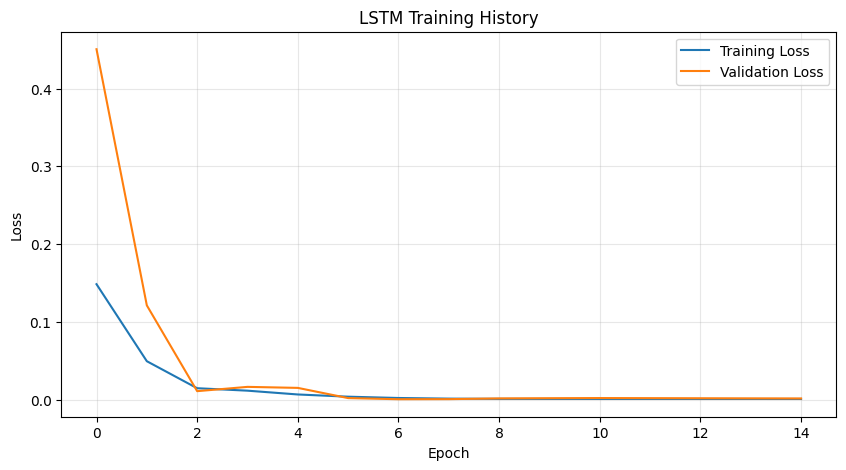

In [44]:
# ============================================================
# LSTM TRAINING CURVE
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

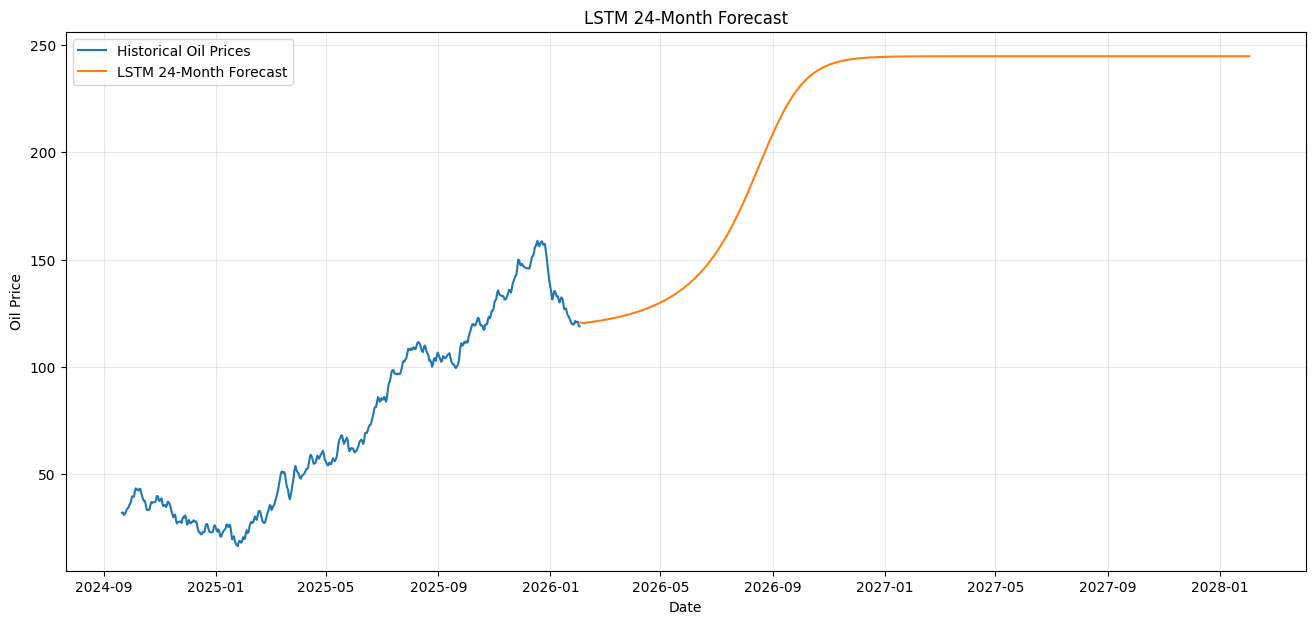

In [45]:
# ============================================================
# LSTM 24-MONTH FUTURE FORECAST
# ============================================================

full_values = df["Price"].values.reshape(-1, 1)
full_scaled = scaler.fit_transform(full_values)

last_sequence = full_scaled[-best_seq:].flatten().tolist()

future_scaled_predictions = []

for _ in range(730):
    x_input = np.array(last_sequence[-best_seq:]).reshape(1, best_seq, 1)
    next_pred_scaled = best_lstm_model.predict(x_input, verbose=0)[0, 0]
    future_scaled_predictions.append(next_pred_scaled)
    last_sequence.append(next_pred_scaled)

future_predictions = scaler.inverse_transform(
    np.array(future_scaled_predictions).reshape(-1, 1)
).flatten()

future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=730,
    freq="D"
)

lstm_forecast_df = pd.DataFrame({
    "Forecast": future_predictions
}, index=future_dates)

plt.figure(figsize=(16, 7))
plt.plot(df.index, df["Price"], label="Historical Oil Prices")
plt.plot(lstm_forecast_df.index, lstm_forecast_df["Forecast"], label="LSTM 24-Month Forecast")
plt.title("LSTM 24-Month Forecast")
plt.xlabel("Date")
plt.ylabel("Oil Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Model Comparison

The final stage compared the three models: ARIMA, Prophet, and LSTM. ARIMA provides a strong classical statistical baseline, Prophet captures interpretable trend and seasonal structure, and LSTM offers a deep learning approach for nonlinear sequential patterns. The models were compared using RMSE, MAE, MAPE, and R² where appropriate.

In [46]:
# ============================================================
# COMBINE MODEL RESULTS
# ============================================================

arima_metrics = {
    "Model": f"ARIMA{best_order}",
    "RMSE": rmse,     # from your ARIMA section
    "MAE": mae,       # from your ARIMA section
    "MAPE": test_mape if "test_mape" in globals() else np.nan,
    "R2": np.nan
}

comparison_results = pd.DataFrame([
    arima_metrics,
    prophet_metrics,
    lstm_metrics
])

comparison_results = comparison_results.sort_values("RMSE").reset_index(drop=True)

print("Model Comparison:")
print(comparison_results)

Model Comparison:
            Model      RMSE       MAE       MAPE        R2
0         Prophet  5.894305  5.099210   3.873471  0.813193
1            LSTM  6.147957  4.624603   3.377826  0.796769
2  ARIMA(4, 2, 6)  9.937609  8.203472  14.935817       NaN


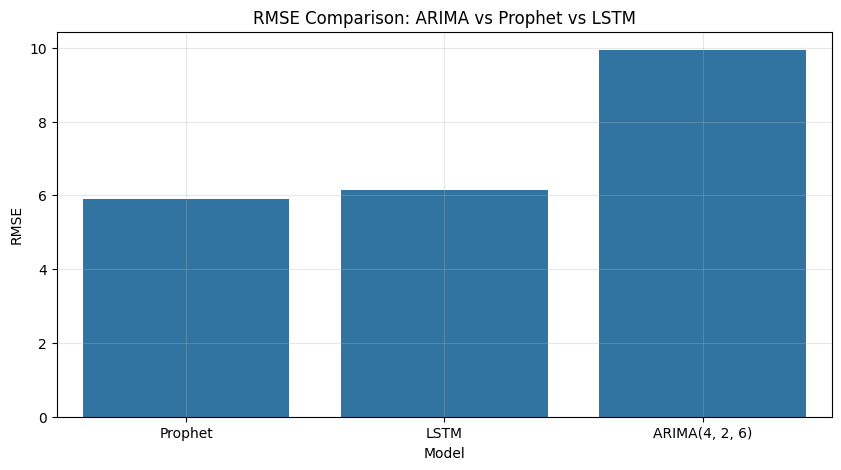

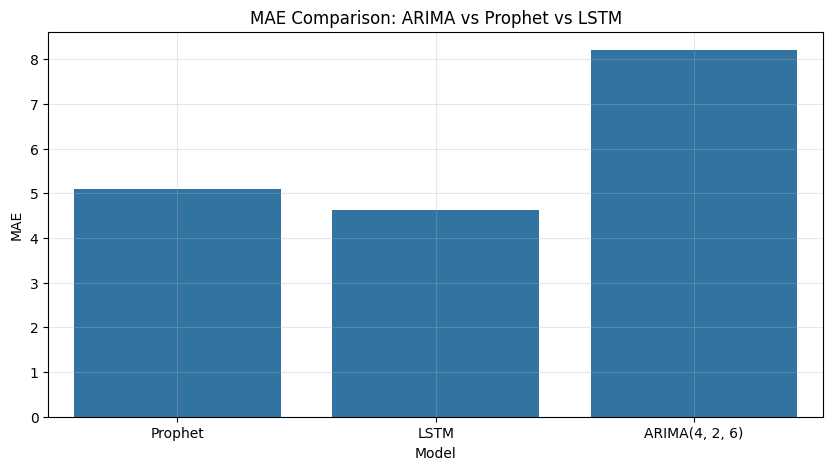

In [47]:
# ============================================================
# MODEL COMPARISON PLOT
# ============================================================

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_results, x="Model", y="RMSE")
plt.title("RMSE Comparison: ARIMA vs Prophet vs LSTM")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_results, x="Model", y="MAE")
plt.title("MAE Comparison: ARIMA vs Prophet vs LSTM")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.grid(True, alpha=0.3)
plt.show()